In [ ]:
from typing import Any, Optional
from arcengine import GameAction


from arcengine import FrameDataRaw

from arc import MyArcSession
from arc_agi import OperationMode
from arc_agi import Arcade
import logging
import numpy as np
from dotenv import load_dotenv
from PIL import Image
from sandbox import SandboxOrchestrator
from google.genai import types
from google import genai
from tools import TOOL_LIST, SYSTEM_PROMPT, TAKE_ACTION
from agent import JackAgent

load_dotenv()


PALETTE = np.array(
    [
        [0xFF, 0xFF, 0xFF],
        [0xCC, 0xCC, 0xCC],
        [0x99, 0x99, 0x99],
        [0x66, 0x66, 0x66],
        [0x33, 0x33, 0x33],
        [0x00, 0x00, 0x00],
        [0xE5, 0x3A, 0xA3],
        [0xFF, 0x7B, 0xCC],
        [0xF9, 0x3C, 0x31],
        [0x1E, 0x93, 0xFF],
        [0x88, 0xD8, 0xF1],
        [0xFF, 0xDC, 0x00],
        [0xFF, 0x85, 0x1B],
        [0x92, 0x12, 0x31],
        [0x4F, 0xCC, 0x30],
        [0xA3, 0x56, 0xD6],
    ],
    dtype=np.uint8,
)


def render_frame(frame: np.ndarray) -> Image.Image:
    rgb = PALETTE[np.clip(np.asarray(frame, dtype=np.uint8), 0, 15)]
    return Image.fromarray(rgb).resize((512, 512), Image.NEAREST)


logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%H:%M:%S"
)


def current_state_prompt(obs: FrameDataRaw) -> str:
    return f"""Currently playing game: {obs.game_id}. On level #{obs.levels_completed} out of #{obs.win_levels}.

"""


def starting_state_prompt(obs: FrameDataRaw) -> str:
    res = f"""Starting the following game: {obs.game_id}

"""

    return (
        f"New game started. Initial state:\n{json.dumps(obs, indent=2)}\n\n"
        f"The full grid is in /home/agent/state.json. "
        f"Start by calling render_board to see the board, then take actions to explore."
    )

In [3]:

arcade = Arcade(operation_mode=OperationMode("normal"))
scorecard_id: str = arcade.open_scorecard(tags=["jackagent"])
arc_session = MyArcSession(
    game_id=["ls20", "ft09"][1], arcade=arcade, scorecard_id=scorecard_id
)
sbx = SandboxOrchestrator()
print(sbx.bash("echo sandbox ready"))

agent = JackAgent(sbx=sbx, arc_session=arc_session)


agent.contents = []

2026-04-13 02:31:50 | INFO | Successfully fetched 25 environment(s) from API


02:31:50 Successfully fetched 25 environment(s) from API


2026-04-13 02:31:50 | INFO | Created new scorecard: 90571dd1-cda4-40ec-bbd0-95e6c11d9ef3


02:31:50 Created new scorecard: 90571dd1-cda4-40ec-bbd0-95e6c11d9ef3


2026-04-13 02:31:50 | INFO | Successfully fetched metadata for game ft09


...

2026-04-13 02:31:51 | INFO | Recording to recordings/90571dd1-cda4-40ec-bbd0-95e6c11d9ef3/ft09-0d8bbf25-9e700497-3080-4aa4-9c21-d0239435f795.jsonl


02:31:51 Recording to recordings/90571dd1-cda4-40ec-bbd0-95e6c11d9ef3/ft09-0d8bbf25-9e700497-3080-4aa4-9c21-d0239435f795.jsonl


2026-04-13 02:31:51 | INFO | Successfully loaded game class Ft09 from environment_files/ft09/0d8bbf25/ft09.py


02:31:51 Successfully loaded game class Ft09 from environment_files/ft09/0d8bbf25/ft09.py


sandbox ready


02:32:00 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


─── take_action ───
  y: 32
  action: ACTION6
  x: 32
  → state=NOT_FINISHED score=0/6 available=['ACTION6']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.


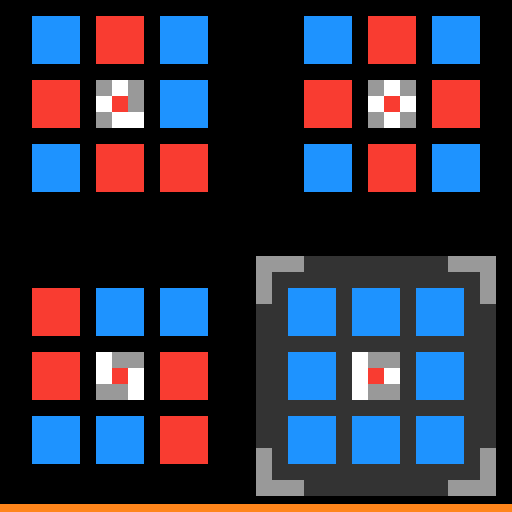

02:32:07 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


─── bash ───
  command: cat /home/agent/state.json | grep -o '\"grid\": \[\[.*\]\]' | head -n 1 | cut -c 1-200
  → "grid": [[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5



02:32:13 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


─── write ───
  content: import json

with open('/home/agent/state.json', 'r') as f:
    state = json.load(f)

grid = state['grid']

# Find all non-5 colors and their bounding box
non_5 = []
for y, row in enumerate(grid):
   
  file_path: /home/agent/inspect_grid.py
  → File successfully written: /home/agent/inspect_grid.py



02:32:16 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


...

─── write ───
  content: import json

with open('/home/agent/state.json', 'r') as f:
    state = json.load(f)

grid = state['grid']

# We need to find the bottom-right inner 6x6 block.
# We know it's framed by 4.
# The bottom
  file_path: /home/agent/find_zeros.py
  → File successfully written: /home/agent/find_zeros.py



02:32:34 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


─── bash ───
  command: python3 /home/agent/find_zeros.py
  → Zero at 44, 44
Zero at 45, 44
Zero at 44, 45
Zero at 45, 45
Zero at 44, 46
Zero at 45, 46
Zero at 48, 46
Zero at 49, 46
Zero at 44, 47
Zero at 45, 47
Zero at 48, 47
Zero at 49, 47
Zero at 44, 48
Zero at 45, 48
Zero at 44, 49
Zero at 45, 49



02:32:37 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


─── take_action ───
  y: 44
  action: ACTION6
  x: 44
  → state=NOT_FINISHED score=0/6 available=['ACTION6']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.


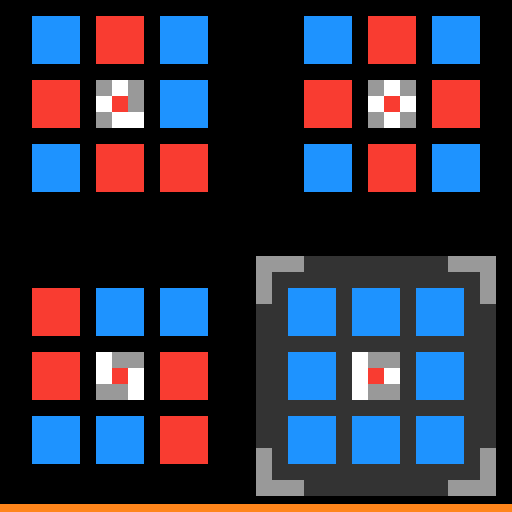

02:32:39 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


─── bash ───
  command: python3 /home/agent/find_zeros.py
  → Zero at 44, 44
Zero at 45, 44
Zero at 44, 45
Zero at 45, 45
Zero at 44, 46
Zero at 45, 46
Zero at 48, 46
Zero at 49, 46
Zero at 44, 47
Zero at 45, 47
Zero at 48, 47
Zero at 49, 47
Zero at 44, 48
Zero at 45, 48
Zero at 44, 49
Zero at 45, 49



02:32:42 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


─── bash ───
  command: cat /home/agent/state.json | grep -o '\"grid\": \[\[.*\]\]' | head -n 1 | cut -c 1-200
  → "grid": [[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5



02:32:47 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


─── bash ───
  command: tail -n 2 /home/agent/replay.jsonl
  → {"timestamp": "2026-04-13T06:32:00.376225+00:00", "data": {"game_id": "ft09-0d8bbf25", "state": "NOT_FINISHED", "levels_completed": 0, "win_levels": 6, "action_input": {"id": "ACTION6", "data": {}, "reasoning": null}, "guid": "9e700497-3080-4aa4-9c21-d0239435f795", "full_reset": false, "available_ac



02:32:50 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


─── take_action ───
  action: ACTION6
  x: 44
  y: 46
  → state=NOT_FINISHED score=0/6 available=['ACTION6']
Current grid and full obs written to /home/agent/state.json. Full action history in /home/agent/replay.jsonl.


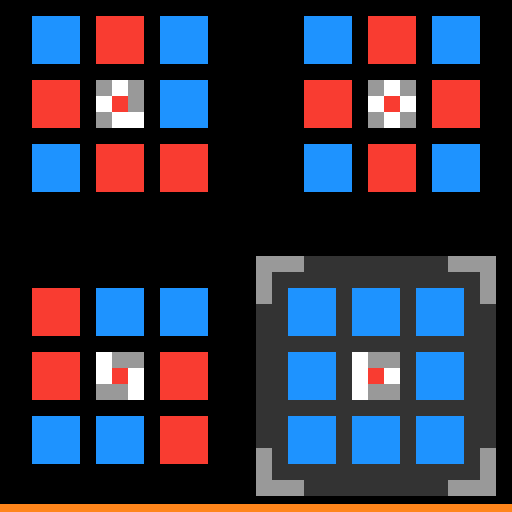

KeyboardInterrupt: 

In [ ]:


agent.contents = [
    types.Content(role="user", parts=[types.Part(text=(
        f"Game: {arc_session.obs.game_id} | "
        f"Score: {arc_session.obs.levels_completed}/{arc_session.obs.win_levels} | "
        f"Actions: {[GameAction.from_id(a).name for a in arc_session.obs.available_actions]}\n\n"
        f"Current grid is in /home/agent/state.json. "
        f"Full action history is in /home/agent/replay.jsonl. "
        f"Solve this game."
    ))])
]

agent.contents.append(types.Content(role="user", parts=[
    types.Part(text="solve quickly")]))

for _ in range(100):
    calls = agent.generate_response()
    for c in calls:
        print(f"[{c['name']}] {c['args']}")
        print(f"  → {str(c['result'])[:300]}\n")
        if c["name"] == "take_action" and agent.arc_session.obs.frame:
            display(render_frame(agent.arc_session.obs.frame[-1]))

In [ ]:
agent.contents

[Content(
   parts=[
     Part(
       text="""This is the current board. {
   "game_id": "ls20-9607627b",
   "state": "NOT_FINISHED",
   "levels_completed": 0,
   "win_levels": 7,
   "action_input": {
     "id": 0,
     "data": {},
     "reasoning": null
   },
   "guid": "3af63412-375d-4d0f-9f63-8fa4f0833a94",
   "full_reset": true,
   "available_actions": [
     1,
     2,
     3,
     4
   ]
 }"""
     ),
   ],
   role='user'
 ),
 Content(
   parts=[
     Part(
       text='solve quickly'
     ),
   ],
   role='user'
 ),
 Content(
   parts=[
     Part(
       function_call=FunctionCall(
         args={
           'action': 'ACTION1'
         },
         id='dvy9fdgp',
         name='take_action'
       ),
       thought_signature=b'\x12\xd9\x01\n\xd6\x01\x01\xbe>\xf6\xfby\xa8\x8f\x92o{\x94:\xd7\x80p \xabAH\x12S\xf8\x087\xdc\x14\x148\xfc\xe6\xcc\xc3\xf4\x969@<\r$Sv\x7fT\xc3\\\xae\xff\xc7\xf6\xda]\xac?A8,}H\xe0%\x1eJ\x9c\xdc\xfc\x9d\x04x\xb4\xfe\xc7\x83\x10\xc6\xba\xaf\x05\x0fP\xd0\xc